# Step 3: Quick EDA

We do a quick EDA on the HUST parsed dataset (time series in csv).

In [1]:
# Load the "autoreload" extension so that code can change
%load_ext autoreload
# Always reload modules so that as you change code in src, it gets loaded
%autoreload 2

import os
from copy import deepcopy
import json
import yaml
import re

import numpy as np
import pandas as pd
from scipy.io import loadmat

import matplotlib.pyplot as plt
import seaborn as sns


## Load metadata

In [3]:
parsed_metadata_path = './data_parsed/csv/parsed_metadata.json'
with open(parsed_metadata_path, 'r') as f:
    parsed_metadata = json.load(f)

In [4]:
len(parsed_metadata)

99

In [5]:
df_parsed_metadata = pd.DataFrame(parsed_metadata)

In [6]:
df_parsed_metadata.head()

,raw_filename,raw_data_path,fault_label,fault_severity,fault_location,bearing_speed,sampling_freq_khz,df_length,df_columns,parsed_data_path
0,0.5X_B_20Hz.xls,./data/0.5X_B_20Hz.xls,M_B,medium,B,20Hz,25.641,262144,"[timestamp, speed, x, y, z]",./data_parsed/csv/0.5X_B_20Hz.csv
1,0.5X_B_25Hz.xls,./data/0.5X_B_25Hz.xls,M_B,medium,B,25Hz,25.641,262144,"[timestamp, speed, x, y, z]",./data_parsed/csv/0.5X_B_25Hz.csv
2,0.5X_B_30Hz.xls,./data/0.5X_B_30Hz.xls,M_B,medium,B,30Hz,25.641,262144,"[timestamp, speed, x, y, z]",./data_parsed/csv/0.5X_B_30Hz.csv
3,0.5X_B_35Hz.xls,./data/0.5X_B_35Hz.xls,M_B,medium,B,35Hz,25.641,262144,"[timestamp, speed, x, y, z]",./data_parsed/csv/0.5X_B_35Hz.csv
4,0.5X_B_40Hz.xls,./data/0.5X_B_40Hz.xls,M_B,medium,B,40Hz,25.641,262144,"[timestamp, speed, x, y, z]",./data_parsed/csv/0.5X_B_40Hz.csv


## Overlaying plots by fault label (fault type and fault location)

In [7]:
paths_by_label = {}
for label in df_parsed_metadata['fault_label'].unique():
    paths_by_label[label] = df_parsed_metadata[df_parsed_metadata['fault_label'] == label]['parsed_data_path'].to_list()


In [9]:
paths_by_label['H']

['./data_parsed/csv/H_20Hz.csv',
 './data_parsed/csv/H_25hz.csv',
 './data_parsed/csv/H_30Hz.csv',
 './data_parsed/csv/H_35Hz.csv',
 './data_parsed/csv/H_40Hz.csv',
 './data_parsed/csv/H_60Hz.csv',
 './data_parsed/csv/H_65Hz.csv',
 './data_parsed/csv/H_70Hz.csv',
 './data_parsed/csv/H_75Hz.csv',
 './data_parsed/csv/H_80Hz.csv',
 './data_parsed/csv/H_VS_0_40_0Hz.csv']

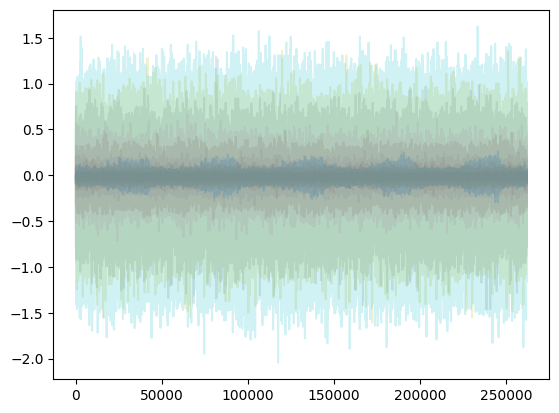

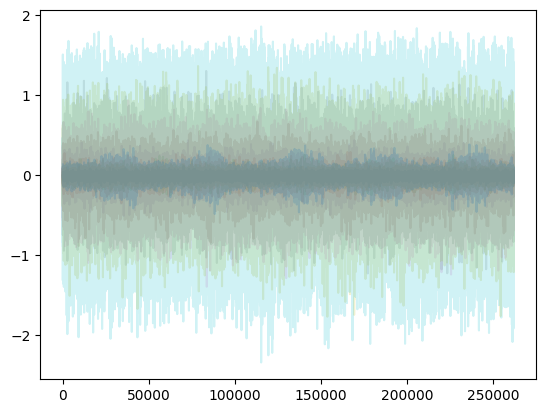

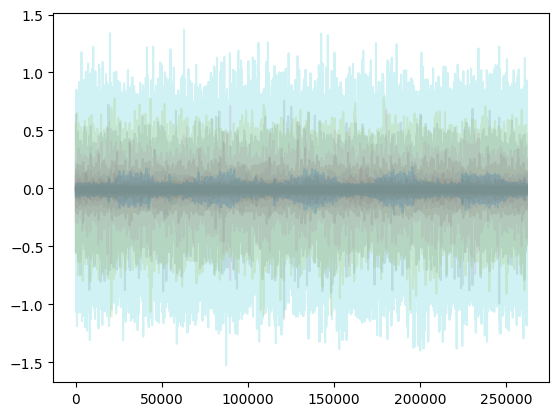

In [11]:
label = 'H'
for n in range(len(paths_by_label[label])):
    pd.read_csv(paths_by_label[label][n])['x'].plot(alpha=0.2)

plt.show()
for n in range(len(paths_by_label[label])):
    pd.read_csv(paths_by_label[label][n])['y'].plot(alpha=0.2)
plt.show()

for n in range(len(paths_by_label[label])):
    pd.read_csv(paths_by_label[label][n])['z'].plot(alpha=0.2)
plt.show()

Normal bearings appears to have different sampling rates (24kHz and 48kHz), instead of the 12kHz as reported

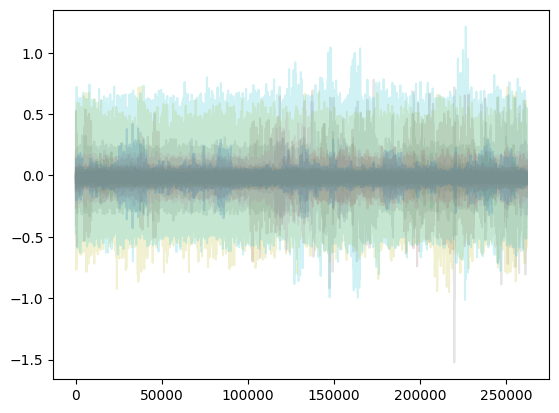

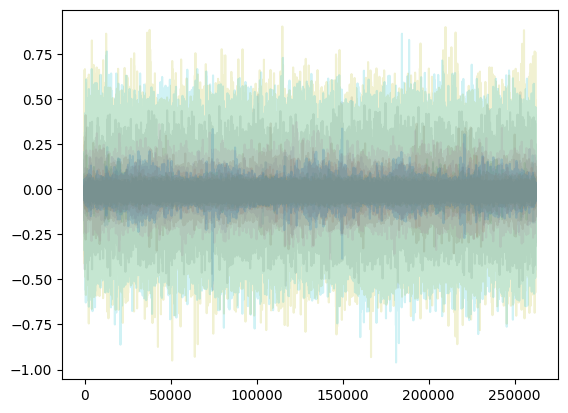

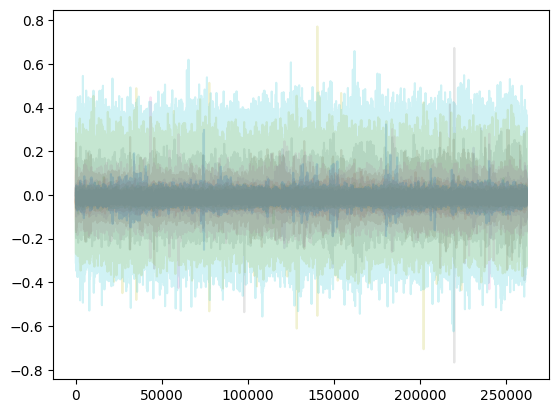

In [14]:
label = 'M_B'
for n in range(len(paths_by_label[label])):
    pd.read_csv(paths_by_label[label][n])['x'].plot(alpha=0.2)

plt.show()
for n in range(len(paths_by_label[label])):
    pd.read_csv(paths_by_label[label][n])['y'].plot(alpha=0.2)
plt.show()

for n in range(len(paths_by_label[label])):
    pd.read_csv(paths_by_label[label][n])['z'].plot(alpha=0.2)
plt.show()

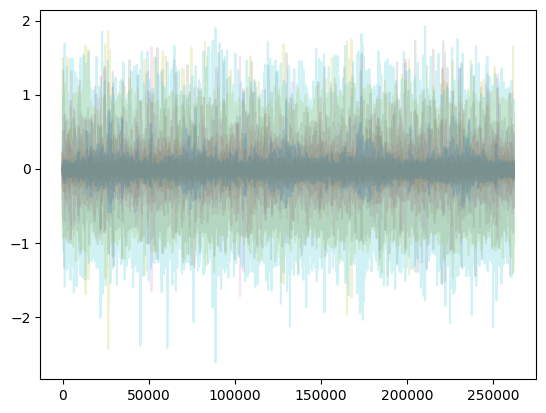

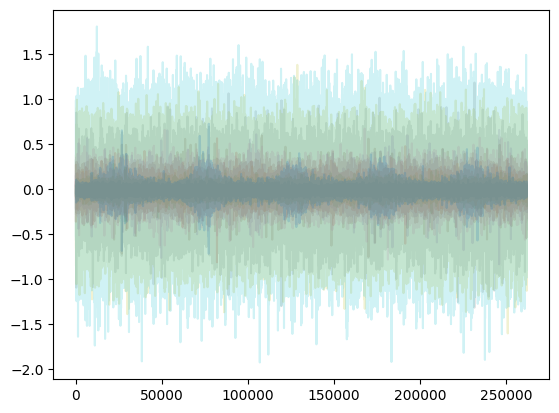

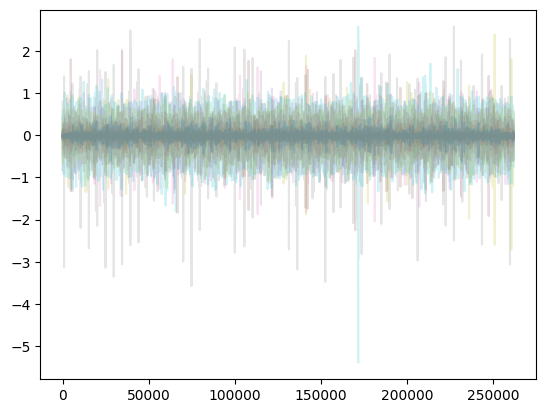

In [15]:
label = 'S_B'
for n in range(len(paths_by_label[label])):
    pd.read_csv(paths_by_label[label][n])['x'].plot(alpha=0.2)

plt.show()
for n in range(len(paths_by_label[label])):
    pd.read_csv(paths_by_label[label][n])['y'].plot(alpha=0.2)
plt.show()

for n in range(len(paths_by_label[label])):
    pd.read_csv(paths_by_label[label][n])['z'].plot(alpha=0.2)
plt.show()

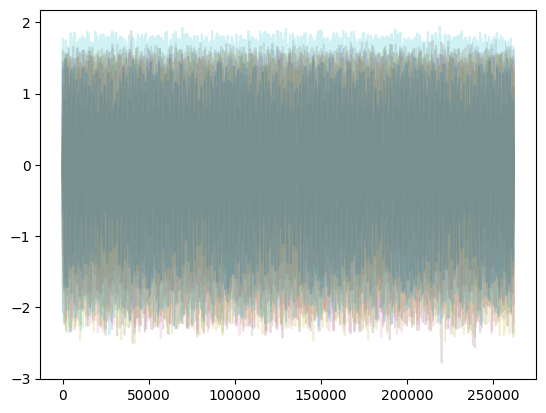

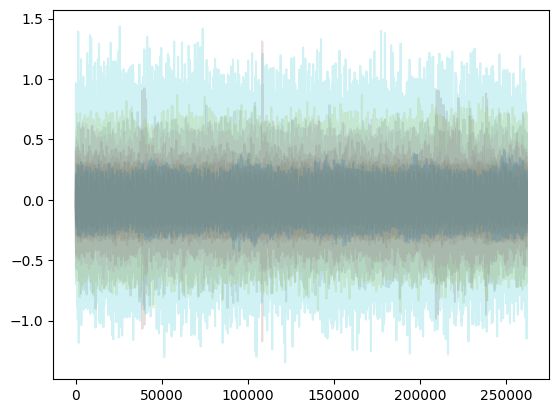

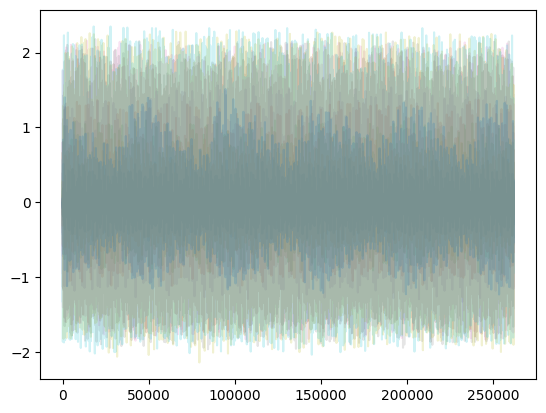

In [16]:
label = 'M_I'
for n in range(len(paths_by_label[label])):
    pd.read_csv(paths_by_label[label][n])['x'].plot(alpha=0.2)

plt.show()
for n in range(len(paths_by_label[label])):
    pd.read_csv(paths_by_label[label][n])['y'].plot(alpha=0.2)
plt.show()

for n in range(len(paths_by_label[label])):
    pd.read_csv(paths_by_label[label][n])['z'].plot(alpha=0.2)
plt.show()

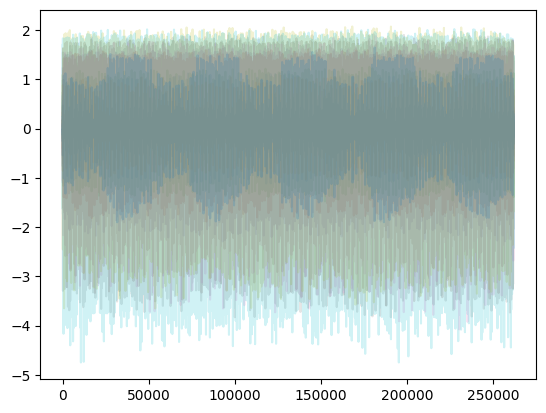

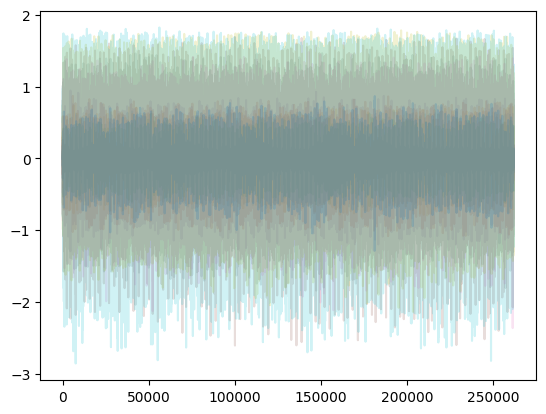

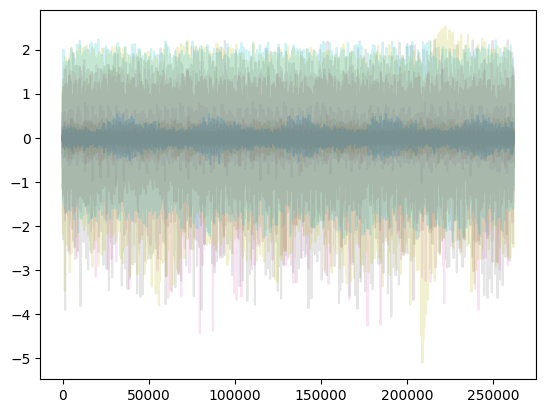

In [17]:
label = 'S_I'
for n in range(len(paths_by_label[label])):
    pd.read_csv(paths_by_label[label][n])['x'].plot(alpha=0.2)

plt.show()
for n in range(len(paths_by_label[label])):
    pd.read_csv(paths_by_label[label][n])['y'].plot(alpha=0.2)
plt.show()

for n in range(len(paths_by_label[label])):
    pd.read_csv(paths_by_label[label][n])['z'].plot(alpha=0.2)
plt.show()

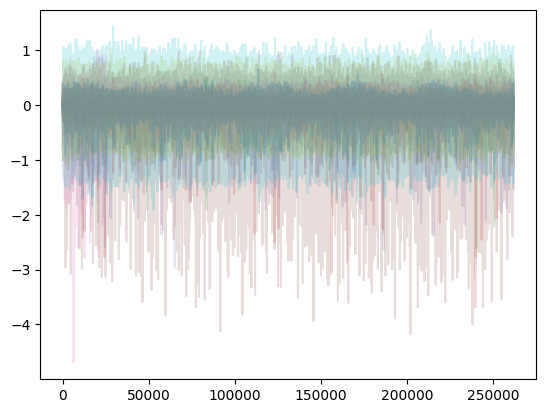

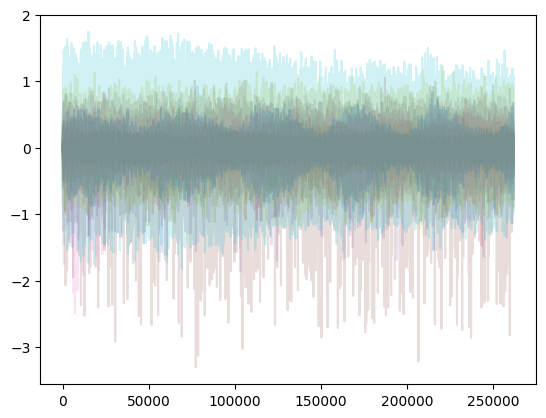

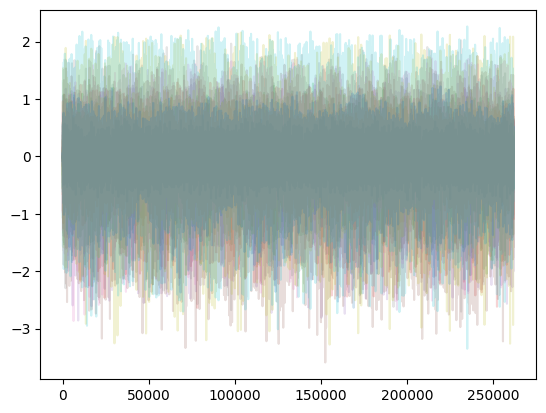

In [18]:
label = 'M_O'
for n in range(len(paths_by_label[label])):
    pd.read_csv(paths_by_label[label][n])['x'].plot(alpha=0.2)

plt.show()
for n in range(len(paths_by_label[label])):
    pd.read_csv(paths_by_label[label][n])['y'].plot(alpha=0.2)
plt.show()

for n in range(len(paths_by_label[label])):
    pd.read_csv(paths_by_label[label][n])['z'].plot(alpha=0.2)
plt.show()

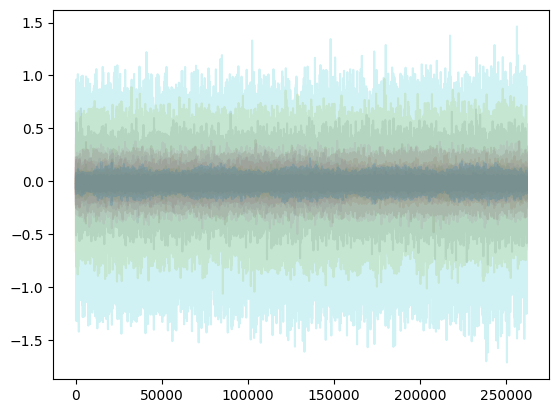

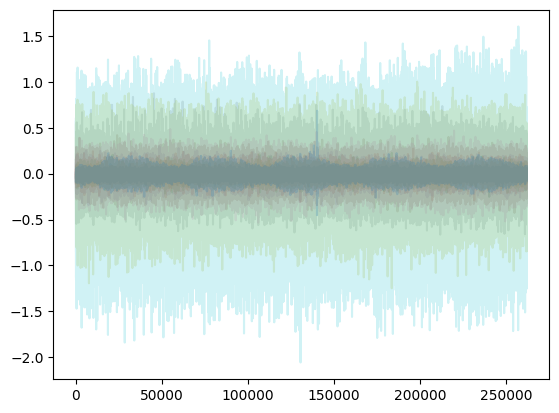

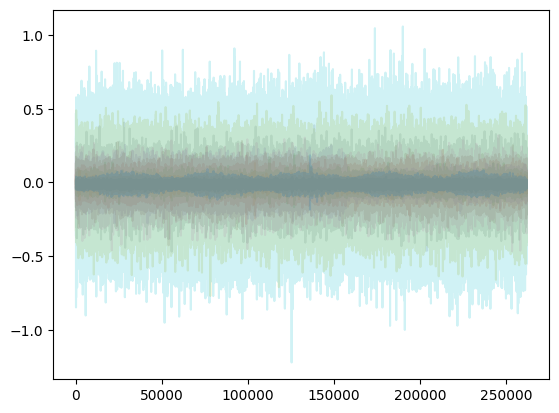

In [19]:
label = 'S_O'
for n in range(len(paths_by_label[label])):
    pd.read_csv(paths_by_label[label][n])['x'].plot(alpha=0.2)

plt.show()
for n in range(len(paths_by_label[label])):
    pd.read_csv(paths_by_label[label][n])['y'].plot(alpha=0.2)
plt.show()

for n in range(len(paths_by_label[label])):
    pd.read_csv(paths_by_label[label][n])['z'].plot(alpha=0.2)
plt.show()

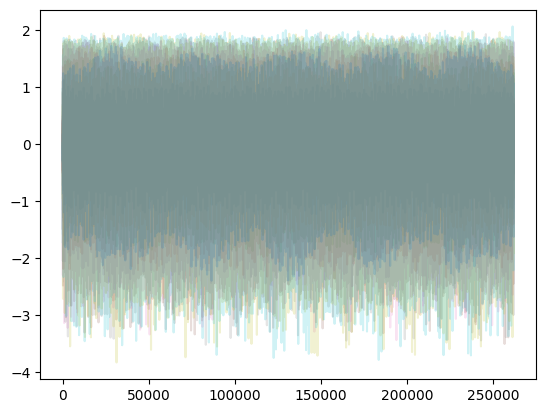

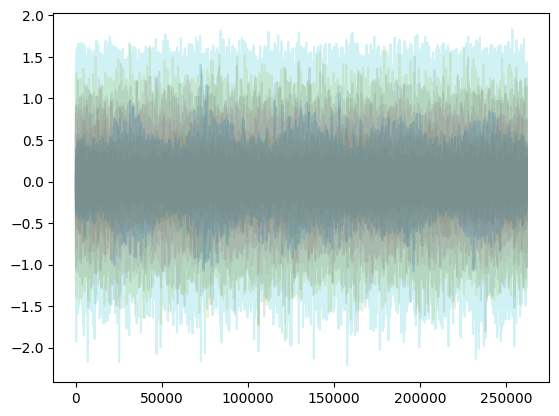

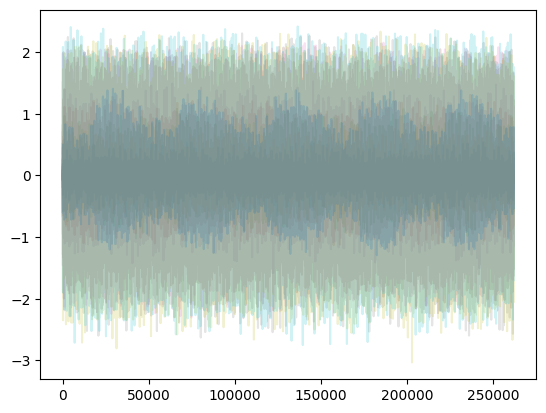

In [20]:
label = 'M_C'
for n in range(len(paths_by_label[label])):
    pd.read_csv(paths_by_label[label][n])['x'].plot(alpha=0.2)

plt.show()
for n in range(len(paths_by_label[label])):
    pd.read_csv(paths_by_label[label][n])['y'].plot(alpha=0.2)
plt.show()

for n in range(len(paths_by_label[label])):
    pd.read_csv(paths_by_label[label][n])['z'].plot(alpha=0.2)
plt.show()

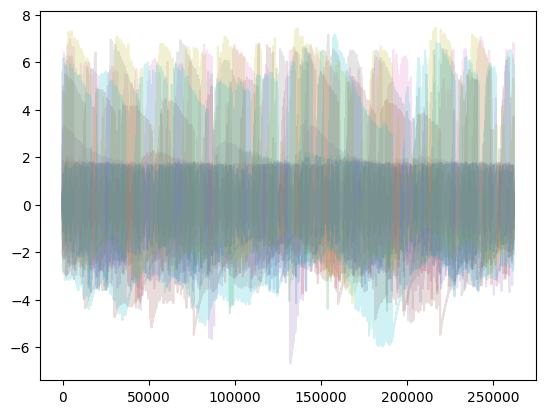

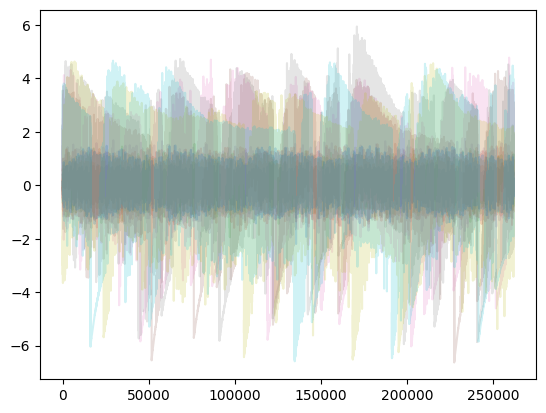

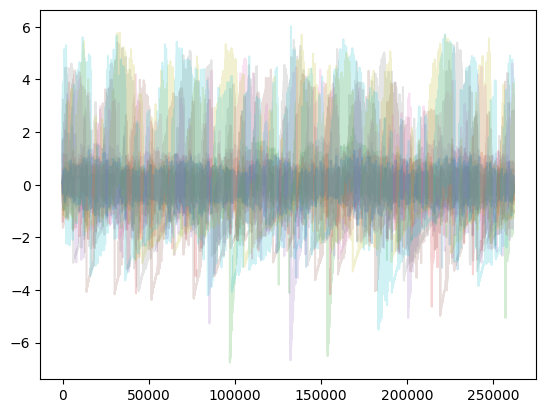

In [21]:
label = 'S_C'
for n in range(len(paths_by_label[label])):
    pd.read_csv(paths_by_label[label][n])['x'].plot(alpha=0.2)

plt.show()
for n in range(len(paths_by_label[label])):
    pd.read_csv(paths_by_label[label][n])['y'].plot(alpha=0.2)
plt.show()

for n in range(len(paths_by_label[label])):
    pd.read_csv(paths_by_label[label][n])['z'].plot(alpha=0.2)
plt.show()

Impression: all time series appear stationary for the duration of recording, except for the combination fault which looks erratic, at first glance

## Average RMS value of each time series by fault label and sub-groups

In [22]:
def get_rms(x):
    rms = np.sqrt(np.mean(np.square(x)))
    return rms

In [23]:
paths_by_label = {}
for label in df_parsed_metadata['fault_label'].unique():
    paths_by_label[label] = df_parsed_metadata[df_parsed_metadata['fault_label'] == label]['parsed_data_path'].to_list()


In [25]:
rms_by_label = {}
for label, paths in paths_by_label.items():
    rms_by_label[label] = {'x_rms': [], 'y_rms': [], 'z_rms': []}
    for path in paths:
        df_ = pd.read_csv(path)[['x', 'y', 'z']]
        rms_by_label[label]['x_rms'].append(get_rms(df_['x'].to_numpy()))
        rms_by_label[label]['y_rms'].append(get_rms(df_['y'].to_numpy()))
        rms_by_label[label]['z_rms'].append(get_rms(df_['z'].to_numpy()))


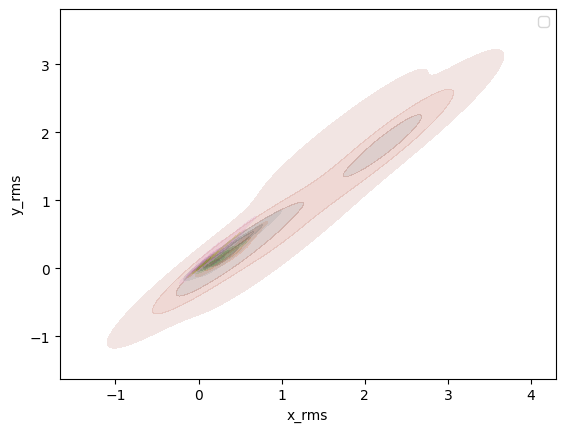

In [26]:
for label in rms_by_label.keys():
    df_ = pd.DataFrame(np.array([rms_by_label[label]['x_rms'], rms_by_label[label]['y_rms']]).T,
                columns=['x_rms', 'y_rms'])
    sns.kdeplot(
        data=df_, x="x_rms", y="y_rms",
        alpha=0.3, fill=True,
        levels=4
    )
plt.legend(list(rms_by_label.keys()))
plt.show()

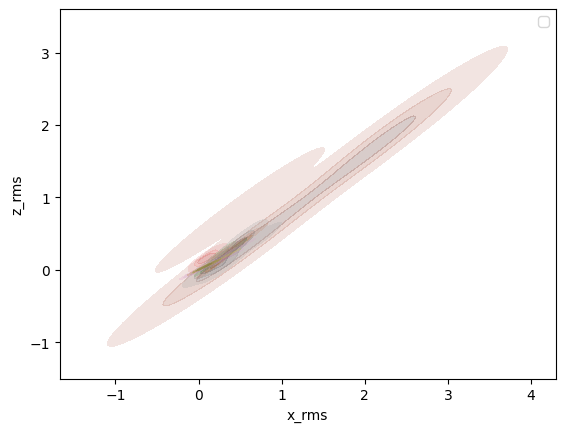

In [27]:
for label in rms_by_label.keys():
    df_ = pd.DataFrame(np.array([rms_by_label[label]['x_rms'], rms_by_label[label]['z_rms']]).T,
                columns=['x_rms', 'z_rms'])
    sns.kdeplot(
        data=df_, x="x_rms", y="z_rms",
        alpha=0.3, fill=True,
        levels=4
    )
plt.legend(list(rms_by_label.keys()))
plt.show()

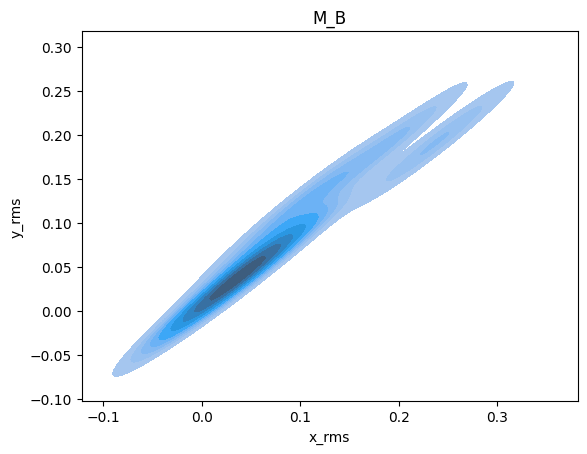

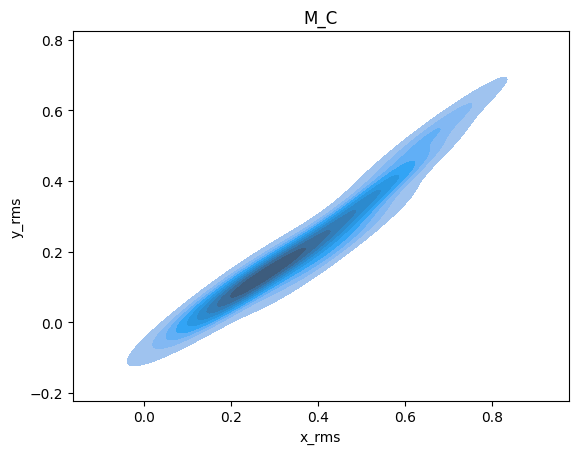

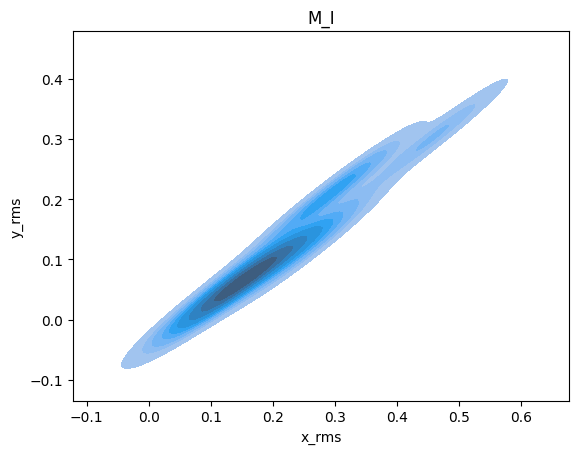

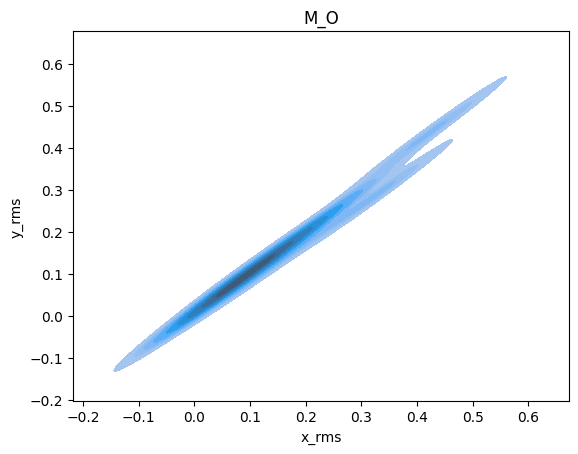

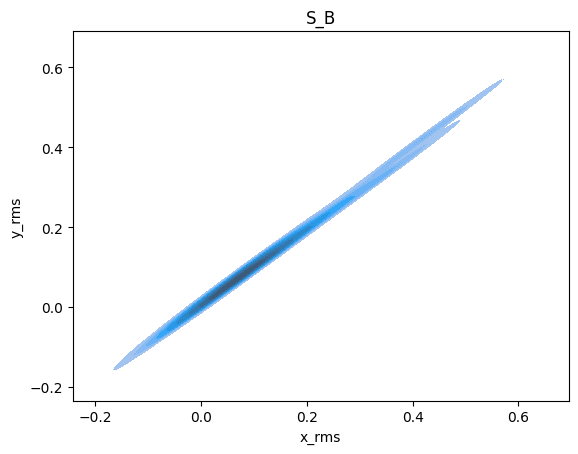

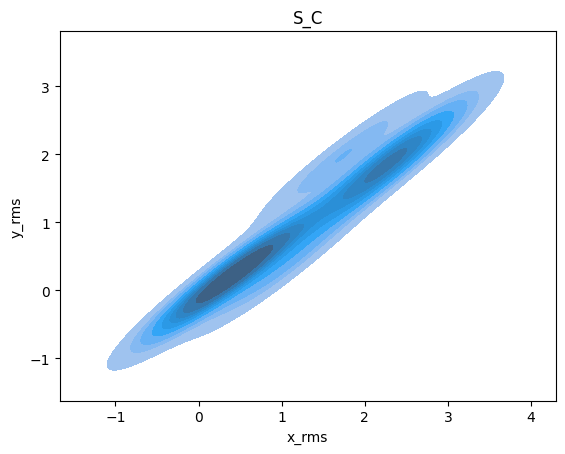

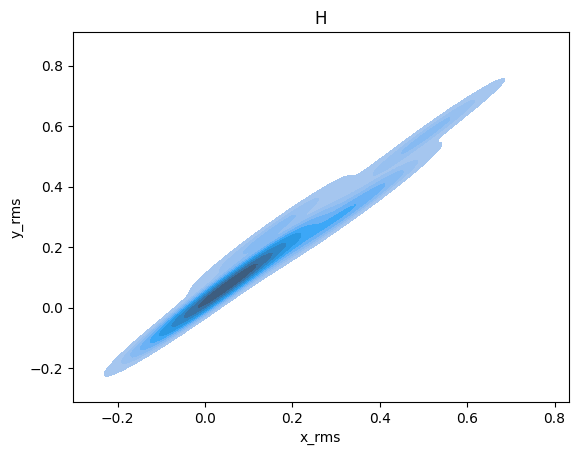

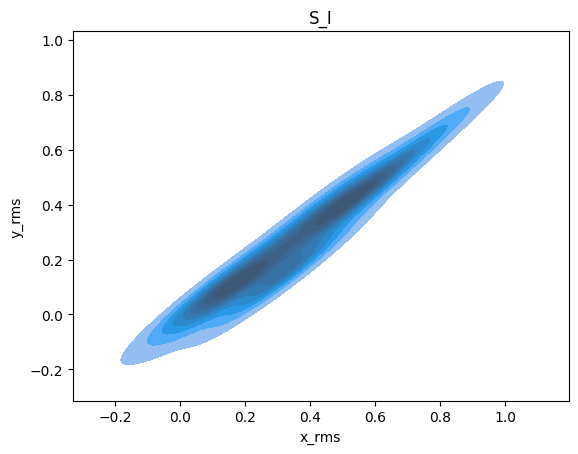

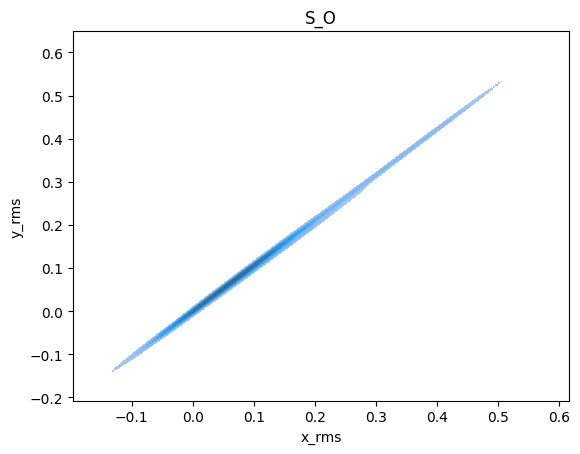

In [30]:
for label in rms_by_label.keys():
    df_ = pd.DataFrame(np.array([rms_by_label[label]['x_rms'], rms_by_label[label]['y_rms']]).T,
                columns=['x_rms', 'y_rms'])
    sns.kdeplot(
        data=df_, x="x_rms", y="y_rms",
        fill=True,
        # levels=4
    )
    plt.title(label)
    plt.show()

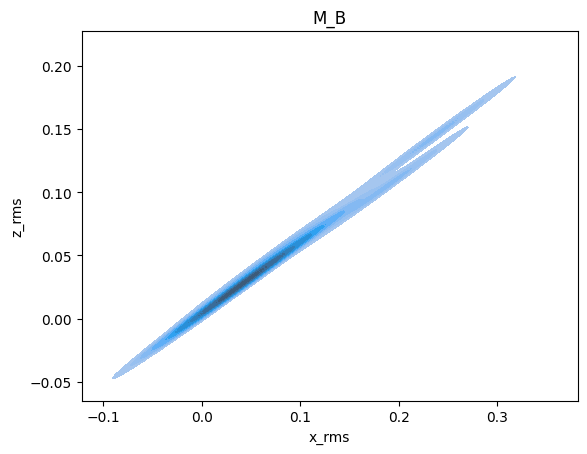

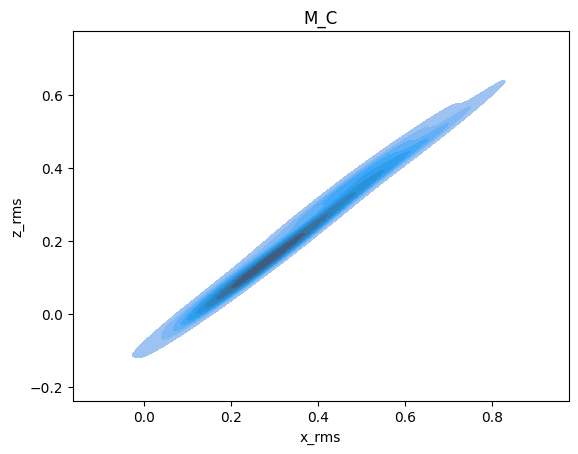

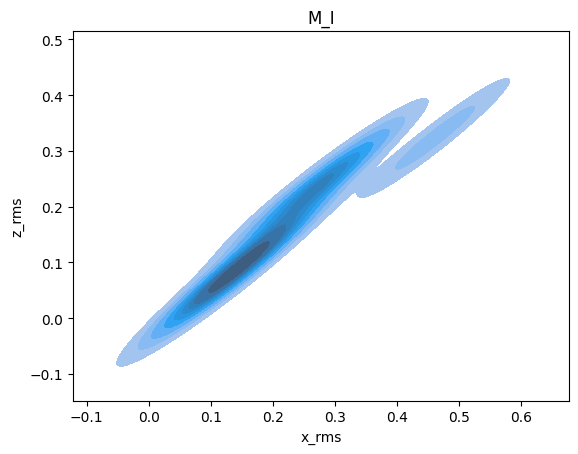

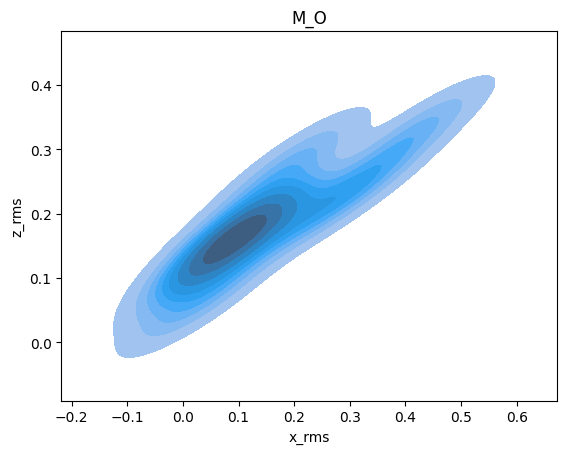

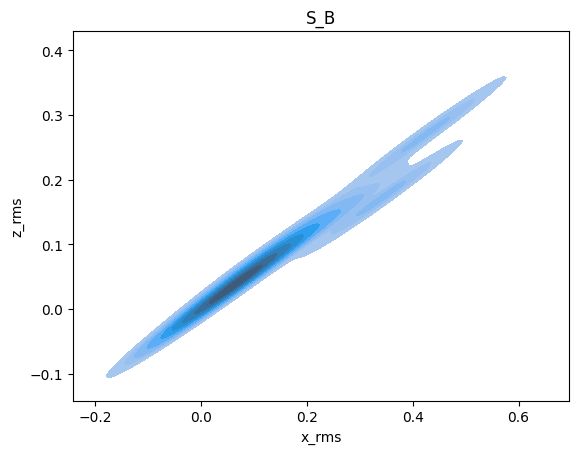

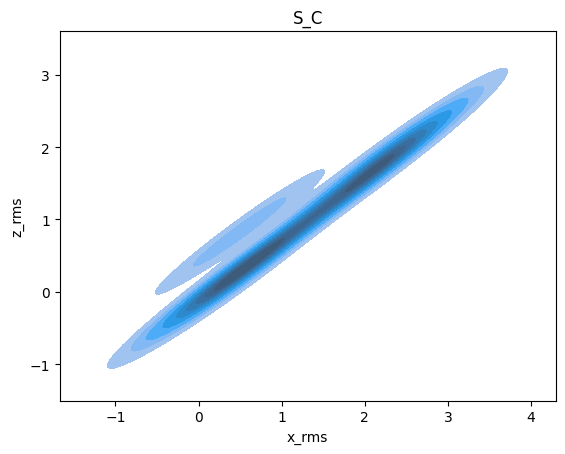

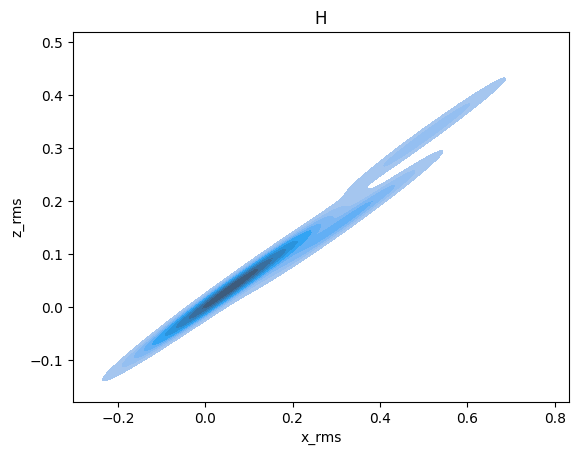

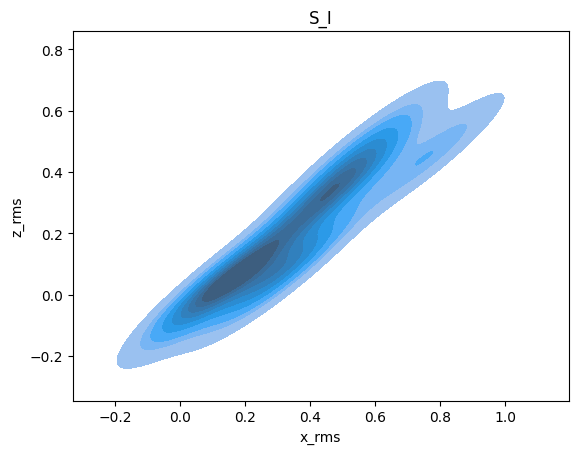

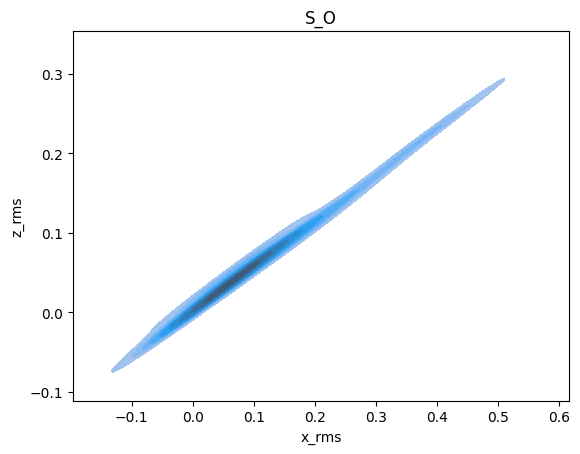

In [31]:
for label in rms_by_label.keys():
    df_ = pd.DataFrame(np.array([rms_by_label[label]['x_rms'], rms_by_label[label]['z_rms']]).T,
                columns=['x_rms', 'z_rms'])
    sns.kdeplot(
        data=df_, x="x_rms", y="z_rms",
        fill=True,
        # levels=4
    )
    plt.title(label)
    plt.show()

RMS exhibit multi-modality in some cases

## RMS by label and fault_diameter

In [175]:
rms_by_label_fault_diameter = {}
for label in df_parsed_metadata['fault_label'].unique():
    rms_by_label_fault_diameter[label] = {}
    df_ = df_parsed_metadata[df_parsed_metadata['fault_label'] == label]
    if label == 'N':
        paths_ = df_['parsed_data_path'].to_list()
        rms_by_label_fault_diameter[label]['None'] = {'DE_rms': [], 'FE_rms': []}
        for path in paths_:
            df__ = pd.read_csv(path)[['DE_time', 'FE_time']]
            rms_by_label_fault_diameter[label]['None']['DE_rms'].append(get_rms(df__['DE_time'].to_numpy()))
            rms_by_label_fault_diameter[label]['None']['FE_rms'].append(get_rms(df__['FE_time'].to_numpy()))
    else:
        for diam in df_['fault_diameter'].unique():
            paths_ = df_[df_['fault_diameter'] == diam]['parsed_data_path'].to_list()
            rms_by_label_fault_diameter[label][diam] = {'DE_rms': [], 'FE_rms': []}
            for path in paths_:
                df__ = pd.read_csv(path)[['DE_time', 'FE_time']]
                rms_by_label_fault_diameter[label][diam]['DE_rms'].append(get_rms(df__['DE_time'].to_numpy()))
                rms_by_label_fault_diameter[label][diam]['FE_rms'].append(get_rms(df__['FE_time'].to_numpy()))


In [189]:
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
mcolors.TABLEAU_COLORS

{'tab:blue': '#1f77b4',
 'tab:orange': '#ff7f0e',
 'tab:green': '#2ca02c',
 'tab:red': '#d62728',
 'tab:purple': '#9467bd',
 'tab:brown': '#8c564b',
 'tab:pink': '#e377c2',
 'tab:gray': '#7f7f7f',
 'tab:olive': '#bcbd22',
 'tab:cyan': '#17becf'}

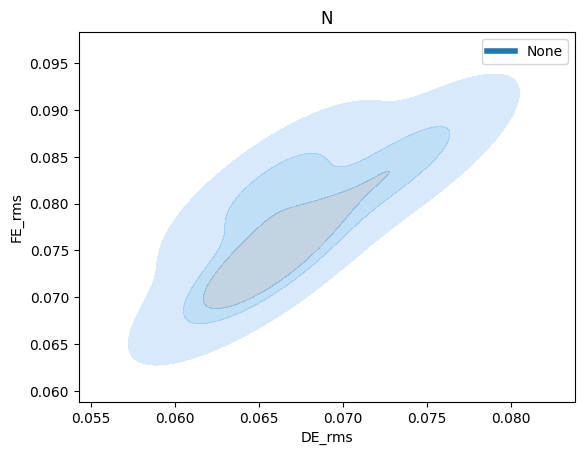

/tmp/ipykernel_370660/3652521601.py:10: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  plots.append(sns.kdeplot(


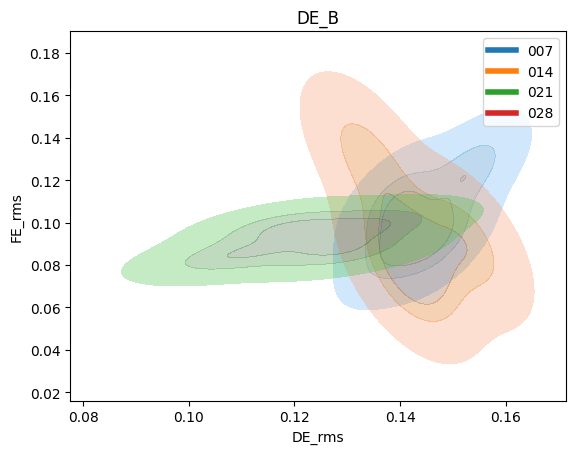

/tmp/ipykernel_370660/3652521601.py:10: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  plots.append(sns.kdeplot(


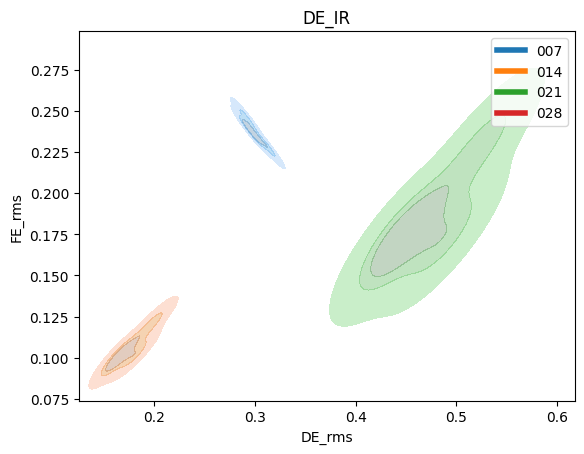

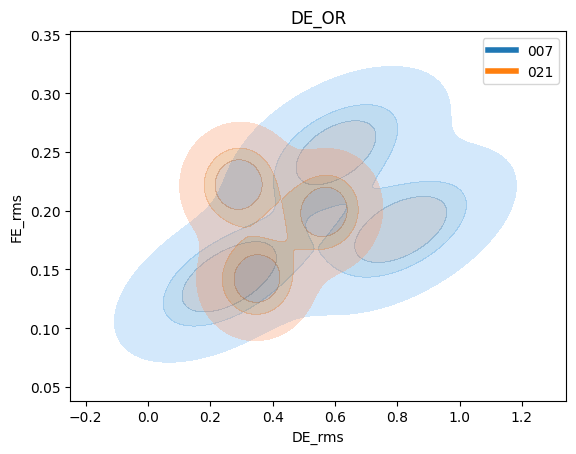

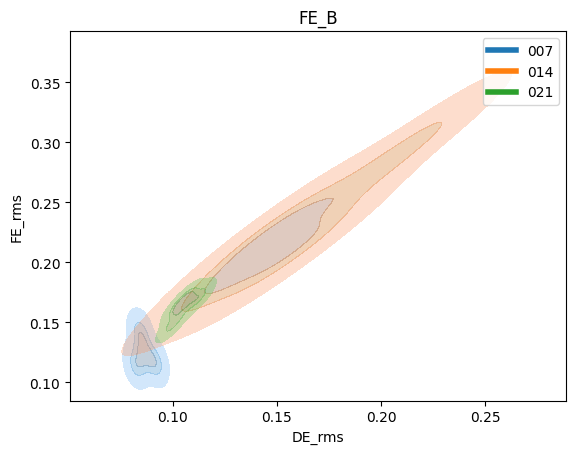

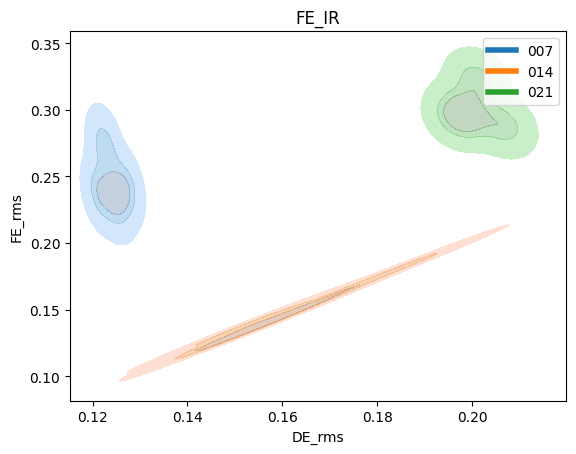

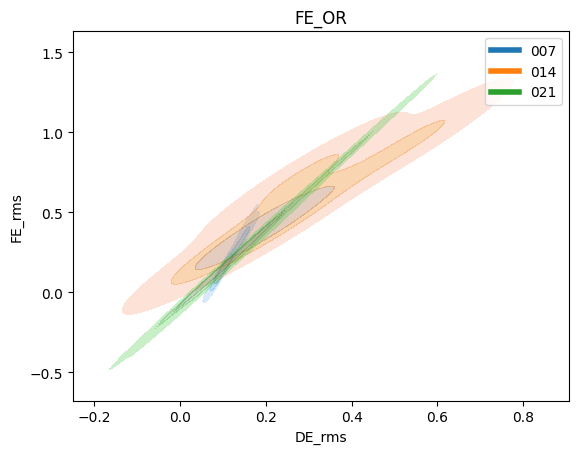

In [191]:
colors = list(mcolors.TABLEAU_COLORS.keys())
for label, dict_ in rms_by_label_fault_diameter.items():
    fig = plt.figure()
    ax = plt.gca()
    legend_lines = []
    for n, (diam, rmss) in enumerate(dict_.items()):
        color=colors[n]
        df_ = pd.DataFrame(np.array([rmss['DE_rms'], rmss['FE_rms']]).T,
                    columns=['DE_rms', 'FE_rms'])
        plots.append(sns.kdeplot(
            data=df_, x="DE_rms", y="FE_rms",
            alpha=0.3, fill=True,
            levels=4, ax=ax, label=diam,
            color=color
        ))
        legend_lines.append(Line2D([0], [0], color=color, lw=4))
    plt.legend(legend_lines, dict_.keys())
    plt.title(label)
    plt.show()

Except for OR fault, the multimodes seem to have been broken down by fault diameter